# Credit Risk Scoring (with Trees and Ensembles Models)

## Data cleaning and preparation

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('CreditScoring.csv')

In [3]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()

In [5]:
status_values = {1: 'ok', 2: 'default', 0: 'unk'}

df.status = df.status.map(status_values)

In [6]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [7]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [8]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [9]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [10]:
for col in ['income', 'assets', 'debt']:
    df[col] = df[col].replace(to_replace=99999999, value=np.nan)

In [11]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [12]:
df.status.value_counts()

ok         3200
default    1254
unk           1
Name: status, dtype: int64

In [13]:
df = df.loc[df.status != 'unk'].reset_index(drop=True)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [16]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [18]:
del df_train['status']
del df_val['status']
del df_test['status']

In [19]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897


## Decision Trees

In [20]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [21]:
xi = df_train.iloc[0].to_dict()

In [22]:
xi

{'seniority': 10,
 'home': 'owner',
 'time': 36,
 'age': 36,
 'marital': 'married',
 'records': 'no',
 'job': 'freelance',
 'expenses': 75,
 'income': 0.0,
 'assets': 10000.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1400}

In [23]:
assess_risk(xi)

'ok'

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer

In [25]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [26]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [27]:
X_train

array([[3.60e+01, 1.00e+03, 1.00e+04, ..., 0.00e+00, 1.00e+01, 3.60e+01],
       [3.20e+01, 1.10e+03, 0.00e+00, ..., 1.00e+00, 6.00e+00, 4.80e+01],
       [4.00e+01, 1.32e+03, 0.00e+00, ..., 0.00e+00, 1.00e+00, 4.80e+01],
       ...,
       [1.90e+01, 4.00e+02, 0.00e+00, ..., 0.00e+00, 1.00e+00, 2.40e+01],
       [4.30e+01, 2.50e+03, 1.80e+04, ..., 0.00e+00, 1.50e+01, 4.80e+01],
       [2.70e+01, 4.50e+02, 5.00e+03, ..., 1.00e+00, 1.20e+01, 4.80e+01]])

In [28]:
dv.get_feature_names()

/home/ls/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [29]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [30]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [31]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [32]:
from sklearn.metrics import roc_auc_score

In [33]:
roc_auc_score(y_val, y_pred)

0.6444079823690393

In [34]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred) # overfiting

1.0

In [35]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [36]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)

print('train', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

print('val', auc)

train 0.7761016984958594
val 0.7389079944782155


In [37]:
dt = DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)

print('train', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

print('val', auc)

train 0.6282660131823559
val 0.6058644740984719


In [38]:
from sklearn.tree import export_text

In [39]:
print(export_text(dt))

|--- feature_25 <= 0.50
|   |--- class: 1
|--- feature_25 >  0.50
|   |--- class: 0



In [40]:
print(export_text(dt, feature_names=dv.get_feature_names()))

|--- records=no <= 0.50
|   |--- class: 1
|--- records=no >  0.50
|   |--- class: 0



/home/ls/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [41]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)

print('train', auc)
print()

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

print('val', auc)
print()

print(export_text(dt, feature_names=dv.get_feature_names()))

train 0.7054989859726213

val 0.6685264343319367

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0



/home/ls/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


## Decision Tree learning algorithm

In [42]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [43]:
# what is the best value of assets to split the data?
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
3,5000,ok
4,5000,ok
0,8000,default
6,9000,ok


In [44]:
from IPython.display import display

In [45]:
print('Measuring the Impurity')
print()

Ts = [0, 2000, 3000, 4000, 5000, 8000]

for T in Ts:
    print(T)
    df_left = df_example.loc[df_example.assets <= T]
    df_right = df_example.loc[df_example.assets > T]
    
    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    
    display(df_right)
    print(df_right.status.value_counts(normalize=True))
    
    print()

Measuring the Impurity

0


,assets,status
2,0,default


default    1.0
Name: status, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


ok         0.571429
default    0.428571
Name: status, dtype: float64

2000


...

default    0.5
ok         0.5
Name: status, dtype: float64

8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


default    0.571429
ok         0.428571
Name: status, dtype: float64


,assets,status
6,9000,ok


ok    1.0
Name: status, dtype: float64



### Finding the best split algorithm

![Decision Tree Algorithm](decision_tree_algorithm.jpeg)

### Stopping criteria

* Group already pure

* Tree reached depth limit

* Group too small to split

## Decision Trees Parameter Tuning

In [46]:
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
                                     
    print('%4s -> %.3f' % (d, auc))

   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.766
   6 -> 0.745
  10 -> 0.686
  15 -> 0.670
  20 -> 0.647
None -> 0.651


In [47]:
for d in [4, 5, 6]:
    for s in [1, 3, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        print('(%4s, %3d) -> %.3f' % (d, s, auc))

(   4,   1) -> 0.761
(   4,   3) -> 0.761
(   4,   5) -> 0.761
(   4,  10) -> 0.761
(   4,  15) -> 0.764
(   4,  20) -> 0.761
(   4, 100) -> 0.756
(   4, 200) -> 0.747
(   4, 500) -> 0.680
(   5,   1) -> 0.766
(   5,   3) -> 0.767
(   5,   5) -> 0.768
(   5,  10) -> 0.762
(   5,  15) -> 0.772
(   5,  20) -> 0.774
(   5, 100) -> 0.763
(   5, 200) -> 0.759
(   5, 500) -> 0.680
(   6,   1) -> 0.758
(   6,   3) -> 0.749
(   6,   5) -> 0.761
(   6,  10) -> 0.778
(   6,  15) -> 0.785
(   6,  20) -> 0.773
(   6, 100) -> 0.776
(   6, 200) -> 0.768
(   6, 500) -> 0.680


In [48]:
scores = []

for d in [4, 5, 6]:
    for s in [1, 3, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [49]:
scores_df = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])

In [50]:
scores_df.sort_values(by='auc', ascending=False)

,max_depth,min_samples_leaf,auc
22,6,15,0.785095
21,6,10,0.778299
24,6,100,0.776434
14,5,20,0.773537
23,6,20,0.773337
13,5,15,0.772142
25,6,200,0.768267
11,5,5,0.768173
9,5,1,0.766938
10,5,3,0.766496


In [51]:
scores_df_pivot = scores_df.pivot(index='min_samples_leaf', columns='max_depth', values='auc')

In [52]:
scores_df_pivot

max_depth,4,5,6
min_samples_leaf,,,
1,0.761283,0.766938,0.748453
3,0.761283,0.766496,0.752797
5,0.761283,0.768173,0.762651
10,0.761283,0.761809,0.778299
15,0.763726,0.772142,0.785095
20,0.760910,0.773537,0.773337
100,0.755937,0.763384,0.776434
200,0.747260,0.759073,0.768267
500,0.679842,0.679842,0.679842


In [53]:
import seaborn as sns

<AxesSubplot:xlabel='max_depth', ylabel='min_samples_leaf'>

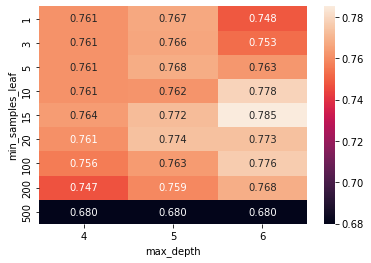

In [54]:
sns.heatmap(scores_df_pivot, annot=True, fmt='.3f')

In [55]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

## Ensemble Learning and Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10)

In [60]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [61]:
roc_auc_score(y_val, y_pred)

0.7795584994308686

In [62]:
rf.predict_proba(X_val[[0]])

array([[0.8, 0.2]])

In [64]:
scores = []
for n in range(10, 201, 10):
    
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    scores.append((n, auc)) # (n trees, auc)

In [66]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

In [67]:
df_scores

,n_estimators,auc
0,10,0.774473
1,20,0.803532
2,30,0.815075
3,40,0.815686
4,50,0.817082
5,60,0.816458
6,70,0.817321
7,80,0.816307
8,90,0.816824
9,100,0.817599


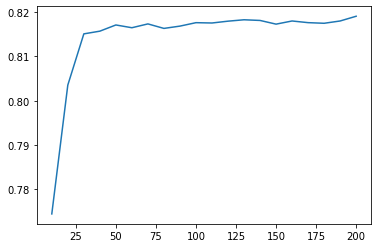

In [69]:
import matplotlib.pyplot as plt

plt.plot(df_scores.n_estimators, df_scores.auc)

In [70]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, n, auc)) # (n trees, auc)

In [72]:
df_scores = pd.DataFrame(scores, columns=['max_depth',
                                          'n_estimators', 'auc'])
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878


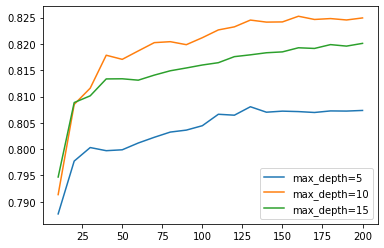

In [73]:
for d in [5, 10, 15]:
    df_subset = df_scores.loc[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, 
            label='max_depth=%d' % d)
    
plt.legend()

In [74]:
max_depth = 10

In [75]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=10,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc)) # (n trees, auc)

In [76]:
df_scores = pd.DataFrame(scores, columns=['min_samples_leaf',
                                          'n_estimators', 'auc'])
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058


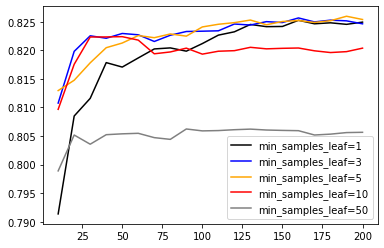

In [78]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
for s, color in zip(min_samples_leaf_values, colors):
    df_subset = df_scores.loc[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, 
             color=color,
            label='min_samples_leaf=%s' % s)
    
plt.legend()

In [79]:
min_samples_leaf = 3

In [82]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
                            # n_jobs=-1
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

In [83]:
auc

0.8233361991717324

### other useful parameters to tune
    # max_features
    # bootstrap

## Gradient Boosting and XGBoost

### Gradient Boosting

![Gradient Boosting Idea](grad_boosting.png)

In [89]:
#!pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 823.7 kB/s eta 0:00:00m eta 0:00:010:00:05

[notice] A new release of pip available: 22.2.2 -> 22.3
[notice] To update, run: pip install --upgrade pip


In [91]:
import xgboost as xgb

In [93]:
features = dv.get_feature_names_out()

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [98]:
xgb_params = {
    'eta': 0.3, # learning rate
    'max_depth': 6,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'nthread': 8, # parallel run 
    
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [96]:
y_pred = model.predict(dval)

In [97]:
roc_auc_score(y_val, y_pred)

0.8003166549611296

In [99]:
watch_lst = [(dtrain, 'train'), (dval, 'val')]

In [103]:
%%capture output

xgb_params = {
    'eta': 0.3, # learning rate
    'max_depth': 6,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                  verbose_eval=5,
                  evals=watch_lst)

In [104]:
print(output.stdout)

[0]	train-auc:0.86300	val-auc:0.76818
[5]	train-auc:0.92863	val-auc:0.80606
[10]	train-auc:0.95002	val-auc:0.81558
[15]	train-auc:0.96558	val-auc:0.81680
[20]	train-auc:0.97316	val-auc:0.81775
[25]	train-auc:0.98174	val-auc:0.81878
[30]	train-auc:0.98772	val-auc:0.81787
[35]	train-auc:0.99180	val-auc:0.81510
[40]	train-auc:0.99456	val-auc:0.81387
[45]	train-auc:0.99596	val-auc:0.81462
[50]	train-auc:0.99688	val-auc:0.81128
[55]	train-auc:0.99787	val-auc:0.80874
[60]	train-auc:0.99889	val-auc:0.80801
[65]	train-auc:0.99919	val-auc:0.80751
[70]	train-auc:0.99944	val-auc:0.80732
[75]	train-auc:0.99964	val-auc:0.80692
[80]	train-auc:0.99985	val-auc:0.80677
[85]	train-auc:0.99986	val-auc:0.80671
[90]	train-auc:0.99992	val-auc:0.80637
[95]	train-auc:0.99996	val-auc:0.80580
[100]	train-auc:0.99998	val-auc:0.80508
[105]	train-auc:0.99999	val-auc:0.80603
[110]	train-auc:1.00000	val-auc:0.80527
[115]	train-auc:1.00000	val-auc:0.80382
[120]	train-auc:1.00000	val-auc:0.80431
[125]	train-auc:1.0000

In [109]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [113]:
df_score = parse_xgb_output(output)

In [114]:
df_score

,num_iter,train_auc,val_auc
0,0,0.86300,0.76818
1,5,0.92863,0.80606
2,10,0.95002,0.81558
3,15,0.96558,0.81680
4,20,0.97316,0.81775
5,25,0.98174,0.81878
6,30,0.98772,0.81787
7,35,0.99180,0.81510
8,40,0.99456,0.81387
9,45,0.99596,0.81462


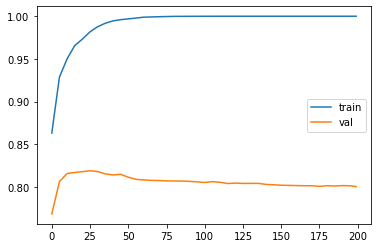

In [115]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

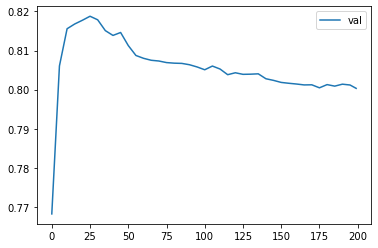

In [116]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

## XGBoost Parameter Tuning

In [118]:
scores = {}

In [127]:
%%capture output

xgb_params = {
    'eta': 0.01, # learning rate (size of the step)
    'max_depth': 6,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                  verbose_eval=5,
                  evals=watch_lst)

In [128]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.01'

In [129]:
scores.keys()

dict_keys(['eta=0.3', 'eta=1.0', 'eta=0.1', 'eta=0.05', 'eta=0.01'])

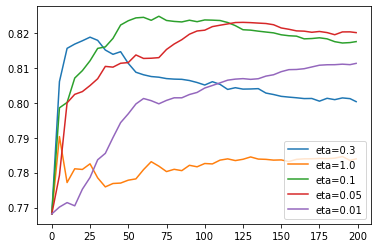

In [130]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.legend()

In [131]:
scores = {}

In [140]:
%%capture output

xgb_params = {
    'eta': 0.1, # learning rate (size of the step)
    'max_depth': 4,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                  verbose_eval=5,
                  evals=watch_lst)

In [141]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=4'

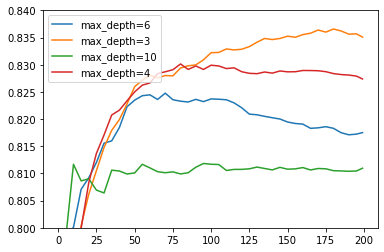

In [142]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)
plt.ylim(0.8, 0.84)
plt.legend()

In [143]:
scores = {}

In [148]:
%%capture output

xgb_params = {
    'eta': 0.1, # learning rate (size of the step)
    'max_depth': 3,
    'min_child_weight': 30, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                  verbose_eval=5,
                  evals=watch_lst)

In [149]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=30'

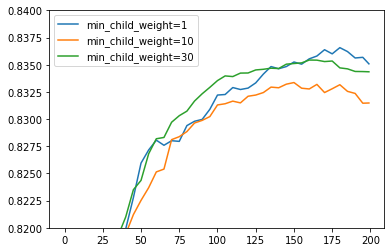

In [153]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)
plt.ylim(0.82, 0.84)
plt.legend()

In [154]:
# final model
xgb_params = {
    'eta': 0.1, # learning rate (size of the step)
    'max_depth': 3,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175, 
                  verbose_eval=5,
                  evals=watch_lst)

[0]	train-auc:0.77424	val-auc:0.73571
[5]	train-auc:0.83122	val-auc:0.77763
[10]	train-auc:0.84733	val-auc:0.78964
[15]	train-auc:0.85566	val-auc:0.80035
[20]	train-auc:0.86359	val-auc:0.80617
[25]	train-auc:0.87161	val-auc:0.81051
[30]	train-auc:0.87855	val-auc:0.81478
[35]	train-auc:0.88298	val-auc:0.81792
[40]	train-auc:0.88701	val-auc:0.81990
[45]	train-auc:0.89137	val-auc:0.82277
[50]	train-auc:0.89458	val-auc:0.82595
[55]	train-auc:0.89884	val-auc:0.82716
[60]	train-auc:0.90159	val-auc:0.82806
[65]	train-auc:0.90380	val-auc:0.82759
[70]	train-auc:0.90650	val-auc:0.82801
[75]	train-auc:0.90935	val-auc:0.82795
[80]	train-auc:0.91110	val-auc:0.82940
[85]	train-auc:0.91298	val-auc:0.82980
[90]	train-auc:0.91428	val-auc:0.82997
[95]	train-auc:0.91655	val-auc:0.83090
[100]	train-auc:0.91801	val-auc:0.83221
[105]	train-auc:0.91981	val-auc:0.83226
[110]	train-auc:0.92205	val-auc:0.83290
[115]	train-auc:0.92301	val-auc:0.83272
[120]	train-auc:0.92460	val-auc:0.83285
[125]	train-auc:0.9261

### other useful parameters
    # subsample and colsample_bytree
    # lambda and alpha
    
https://xgboost.readthedocs.io/en/stable/

## Selecting the Best Model

In [155]:
# best decision tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [156]:
# best random forest 
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
                            # n_jobs=-1
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, random_state=1)

In [159]:
# best xgboost
xgb_params = {
    'eta': 0.1, # learning rate (size of the step)
    'max_depth': 3,
    'min_child_weight': 1, # min leaf
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8, # parallel run 
    'seed': 1, # randomisation
    'verbosity': 1, # type of warnings
}

xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=175, 
                  verbose_eval=5)

In [161]:
for model, validation in [(dt, X_val), (rf, X_val), (xgb_model, dval)]:
    print(str(model))
    y_pred = model.predict(validation)
    auc = roc_auc_score(y_val, y_pred)
    
    print('auc=%s' % auc)
    print('---')

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
auc=0.6992807149257707
---
RandomForestClassifier(max_depth=10, min_samples_leaf=3, random_state=1)
auc=0.6641005303819234
---
auc=0.8360387251459157
---


### training the final model with the entire training set

In [163]:
df_full_train = df_full_train.reset_index(drop=True)

In [164]:
y_full_train = (df_full_train.status == 'default').astype(int).values

del df_full_train['status']

dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                    feature_names=dv.get_feature_names())

dtest = xgb.DMatrix(X_test, feature_names=dv.get_feature_names())

xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

y_pred = model.predict(dtest)
print(roc_auc_score(y_test, y_pred))

/home/ls/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


0.8322662626460096


## Summary

* Decision trees learn if-then-else rules from data.

* Finding the best split: select the least impure split. This algorithm can overfit, that's why we control it by limiting the max depth and the size of the group.

* Random forest is a way of combininig multiple decision trees. It should have a diverse set of models to make good predictions.

* Gradient boosting trains model sequentially: each model tries to fix errors of the previous model. XGBoost is an implementation of gradient boosting.

## Explore more

* For this dataset we didn't do EDA or feature engineering. You can do it to get more insights into the problem.

* For random forest, there are more parameters that we can tune. Check max_features and bootstrap.

* There's a variation of random forest caled "extremely randomized trees", or "extra trees". Instead of selecting the best split among all possible thresholds, it selects a few thresholds randomly and picks the best one among them. Because of that extra trees never overfit. In Scikit-Learn, they are implemented in ExtraTreesClassifier. Try it for this project.

* XGBoost can deal with NAs - we don't have to do fillna for it. Check if not filling NA's help improve performance.

* Experiment with other XGBoost parameters: subsample and colsample_bytree.

* When selecting the best split, decision trees find the most useful features. This information can be used for understanding which features are more important than otheres. See example here for random forest (it's the same for plain decision trees) and for xgboost

* Trees can also be used for solving the regression problems: check DecisionTreeRegressor, RandomForestRegressor and the objective=reg:squarederror parameter for XGBoost.